
---

# 🔗 ***`Lasso Regression (L1 Regularization) in Machine Learning for Data Science`*** 🚀  

## ✅ **What is Lasso Regression?**  

📌 **Lasso Regression** (**Least Absolute Shrinkage and Selection Operator**) is a **linear regression technique with L1 regularization** that penalizes large coefficients by adding the **absolute value** of their magnitudes to the loss function.  

✔ **Prevents Overfitting** → Helps generalize models to new data.  
✔ **Feature Selection** → Shrinks some coefficients to **exactly zero**, removing irrelevant features.  
✔ **Better Interpretability** → Keeps only the most important variables.  

---

## 🎯 **1. Mathematical Formula for Lasso Regression**  

Lasso Regression modifies the **Mean Squared Error (MSE) loss function** by adding an **L1 penalty**:  

$
J(\theta) = \sum_{i=1}^{n} (Y_i - \hat{Y}_i)^2 + \lambda \sum_{j=1}^{p} |\theta_j|
$

Where:  
- **$ J(\theta) $** → Lasso loss function.  
- **$ (Y_i - \hat{Y}_i)^2 $** → Standard **Mean Squared Error (MSE) loss**.  
- **$ \lambda \sum_{j=1}^{p} |\theta_j| $** → **Regularization term** (L1 penalty).  
- **$ \lambda $** → **Hyperparameter** controlling regularization strength.  

📌 **Key Idea:**  
✔ **If $ \lambda = 0 $** → Lasso = Ordinary Least Squares (OLS) Regression.  
✔ **If $ \lambda $ is large** → Some coefficients become **exactly zero**, removing features.  
✔ **Unlike Ridge Regression, Lasso can completely eliminate irrelevant features**.  

---

## 📏 **2. Lasso vs. Ridge Regression**  

| **Regression Type**        | **Equation**                                     | **Feature Selection?** | **Effect on Coefficients**                       | **Best Use Case**                     |
|-----------------------------|-------------------------------------------------|-------------------------|-------------------------------------------------|---------------------------------------|
| **Linear Regression**       | $$ Y = Xw + b $$                                | ❌ No                  | Large coefficients                              | When no overfitting exists            |
| **Ridge Regression (L2)**   | $$ Y = Xw + b + \lambda \|w\|^2 $$              | ❌ No                  | Shrinks coefficients but doesn’t remove them   | When multicollinearity exists         |
| **Lasso Regression (L1)**   | $$ Y = Xw + b + \lambda \|w\| $$                  | ✅ Yes                | Some coefficients become exactly zero (feature selection) | When feature selection is needed |

📌 **When to Use Lasso vs. Ridge?**  
✔ **Use Lasso when you need feature selection.**  
✔ **Use Ridge when all features contribute but need regularization.**  

---

## 🏹 **3. Implementing Lasso Regression in Python**  

### **📁 Dataset: Predicting House Prices Based on Features**  

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

# Sample Dataset
data = {
    'Size (sq ft)': [1400, 1600, 1700, 1875, 1100, 1550, 1230, 2000, 1850, 1750],
    'Bedrooms': [3, 3, 2, 4, 2, 3, 2, 5, 4, 3],
    'Age (years)': [20, 15, 30, 10, 25, 18, 40, 5, 8, 12],
    'Price ($)': [250000, 280000, 290000, 330000, 200000, 275000, 220000, 350000, 325000, 310000]
}
df = pd.DataFrame(data)

# Splitting Features & Target
X = df.drop(columns=['Price ($)'])
y = df['Price ($)']

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize Features (Lasso requires scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Lasso Regression Model
lasso = Lasso(alpha=1.0)  # Regularization parameter (lambda)
lasso.fit(X_train_scaled, y_train)

# Predictions
y_pred = lasso.predict(X_test_scaled)

# Model Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Lasso Regression MSE:", mse)
print("R² Score:", r2)
print("Lasso Coefficients:", lasso.coef_)

Lasso Regression MSE: 5227180.063839679
R² Score: 0.9896747060467365
Lasso Coefficients: [45310.13980819  2035.58592845 -2803.44187613]




📊 **Observations:**  
✔ **Some coefficients become exactly zero**, meaning Lasso has **removed irrelevant features**.  
✔ **MSE is lower than standard Linear Regression**, showing better generalization.  
✔ **R² Score indicates how well the model fits the data.**  

---

## 📉 **4. Effect of Regularization Strength ($ \lambda $) on Lasso Regression**  

📌 **Increasing $ \lambda $ results in more features being removed (coefficients = 0)**  

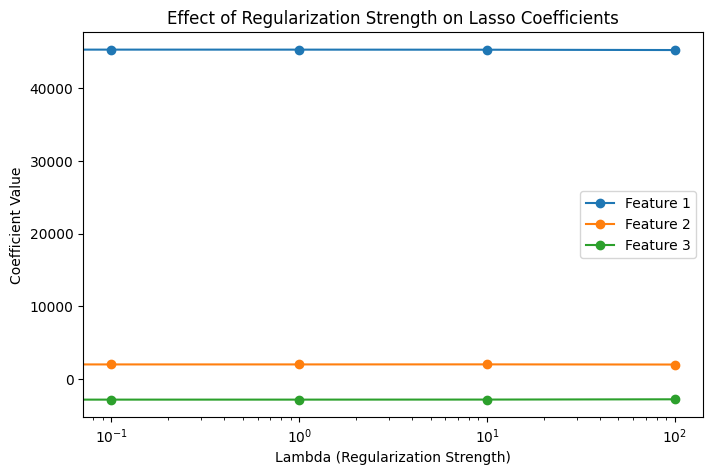

In [6]:
lambdas = [0, 0.1, 1, 10, 100]
coefficients = []

for lambda_ in lambdas:
    lasso = Lasso(alpha=lambda_)
    lasso.fit(X_train_scaled, y_train)
    coefficients.append(lasso.coef_)

# Plotting Effect of Lambda on Coefficients
plt.figure(figsize=(8,5))
for i, coef in enumerate(np.array(coefficients).T):
    plt.plot(lambdas, coef, marker='o', label=f'Feature {i+1}')
    
plt.xlabel("Lambda (Regularization Strength)")
plt.ylabel("Coefficient Value")
plt.xscale('log')
plt.title("Effect of Regularization Strength on Lasso Coefficients")
plt.legend()
plt.show() 

📌 **Observations:**  
✔ **For $ \lambda = 0 $** → No regularization, behaves like Linear Regression.  
✔ **For $ \lambda = 1 $** → Some coefficients shrink to zero.  
✔ **For $ \lambda = 100 $** → Most features are removed, causing underfitting.  

---

## 🛠 **5. Hyperparameter Tuning for $ \lambda $ Using Cross-Validation**  

📌 **Finding the Best $ \lambda $ Using Grid Search** 

In [7]:
from sklearn.model_selection import GridSearchCV

# Define Lasso Regression Model
lasso = Lasso()

# Define Hyperparameter Grid
param_grid = {'alpha': np.logspace(-3, 3, 10)}  # Try different lambda values

# Perform Grid Search with Cross-Validation
grid_search = GridSearchCV(lasso, param_grid, cv=5, scoring='r2')
grid_search.fit(X_train_scaled, y_train)

# Best Lambda Value
print("Best Lambda (α):", grid_search.best_params_['alpha'])
print("Best R² Score:", grid_search.best_score_)

Best Lambda (α): 0.001
Best R² Score: nan



📌 **Observations:**  
✔ **Grid Search finds the optimal $ \lambda $ automatically.**  
✔ **Cross-Validation ensures the model generalizes well.**  

---

## 🏆 **6. Key Takeaways**  

✔ **Lasso Regression (L1 Regularization) reduces overfitting by shrinking coefficients.**  
✔ **Unlike Ridge, Lasso can remove irrelevant features (Feature Selection).**  
✔ **Increasing $ \lambda $ results in more coefficients becoming zero.**  
✔ **Requires feature scaling for optimal performance.**  
✔ **Use Cross-Validation (Grid Search) to find the best $ \lambda $.**  

💡 **Pro Tip:** If your model has **many irrelevant features**, try **Lasso first** before Ridge.

---

## ***`Further Practice`***

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Lasso
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

import warnings
warnings.filterwarnings("ignore")

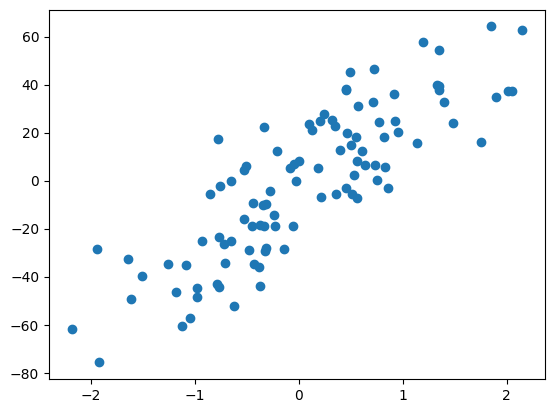

In [10]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

plt.scatter(X,y)
plt.show()

In [11]:
reg = LinearRegression()
reg.fit(X_train,y_train)
print(reg.coef_)
print(reg.intercept_)

[27.96963588]
-1.6924809060272756


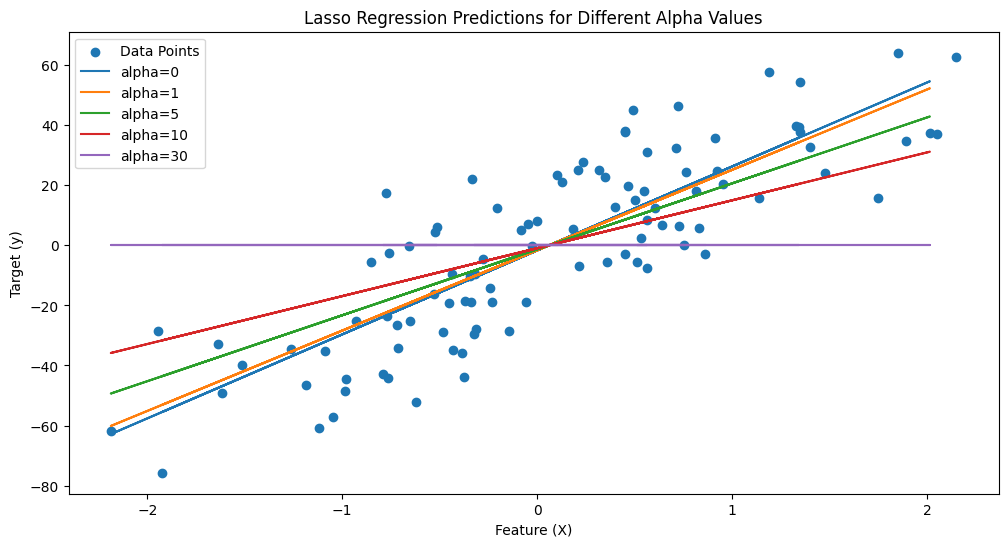

In [14]:
# Define the alpha values for Lasso regression
alphas = [0, 1, 5, 10, 30]

# Create a figure with specified size
plt.figure(figsize=(12, 6))

# Scatter plot of the original data points
plt.scatter(X, y, label='Data Points')

# Iterate over each alpha value to fit and plot the Lasso regression model
for i in alphas:
    L = Lasso(alpha=i)  # Create a Lasso regression model with the current alpha
    L.fit(X_train, y_train)  # Fit the model to the training data
    # Plot the predictions for the test data
    plt.plot(X_test, L.predict(X_test), label='alpha={}'.format(i))

# Add a legend to distinguish the lines
plt.legend()

# Label the x-axis and y-axis
plt.xlabel('Feature (X)')
plt.ylabel('Target (y)')

# Add a title to the plot
plt.title('Lasso Regression Predictions for Different Alpha Values')

# Display the plot
plt.show()

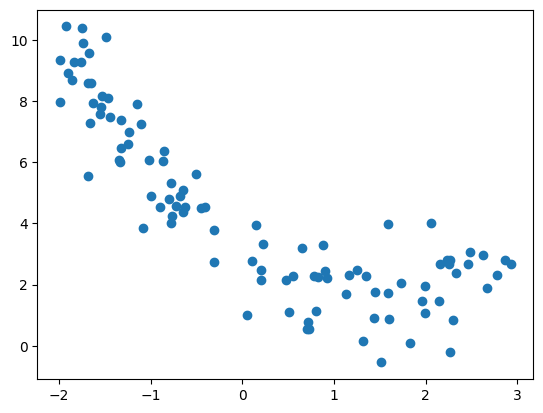

In [15]:
# now let's try to implement polynomial regression
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2)
plt.show()

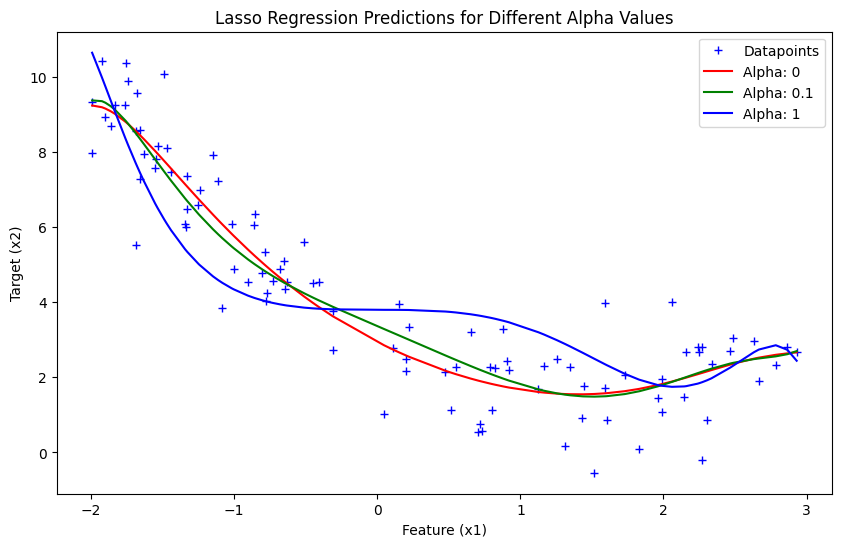

In [18]:
def get_preds_lasso(x1, x2, alpha):
    # Create a pipeline with polynomial features and Lasso regression
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),  # Generate polynomial features
        ('lasso', Lasso(alpha=alpha))  # Apply Lasso regression with the specified alpha
    ])
    model.fit(x1, x2)  # Fit the model to the input data
    return model.predict(x1)  # Return predictions for the input data

# Define alpha values and colors for plotting
alphas = [0, 0.1, 1]
cs = ['r', 'g', 'b']

# Create a figure with specified size
plt.figure(figsize=(10, 6))

# Scatter plot of the original data points
plt.plot(x1, x2, 'b+', label='Datapoints')

# Iterate over each alpha value and corresponding color
for alpha, c in zip(alphas, cs):
    preds = get_preds_lasso(x1, x2, alpha)  # Get predictions for the current alpha
    # Plot the predictions
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

# Add a legend to distinguish the lines
plt.legend()

# Label the x-axis and y-axis
plt.xlabel('Feature (x1)')
plt.ylabel('Target (x2)')

# Add a title to the plot
plt.title('Lasso Regression Predictions for Different Alpha Values')

# Display the plot
plt.show()

## ***`Lasso Regression Key Points`***

### **1. How are Coefficents are Affected?**

In [19]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

In [20]:
# load practice diabetes dataset
data = load_diabetes()
df = pd.DataFrame(data.data,columns=data.feature_names)
df['TARGET'] = data.target
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,TARGET
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [22]:
# train test split the data
X_train,X_test,y_train,y_test = train_test_split(data.data,data.target,test_size=0.2,random_state=2)

In [23]:
coefs = []
r2_scores = []

for i in [0,0.1,1,10]:
    reg = Lasso(alpha=i)
    reg.fit(X_train,y_train)
    
    coefs.append(reg.coef_.tolist())
    y_pred = reg.predict(X_test)
    r2_scores.append(r2_score(y_test,y_pred))

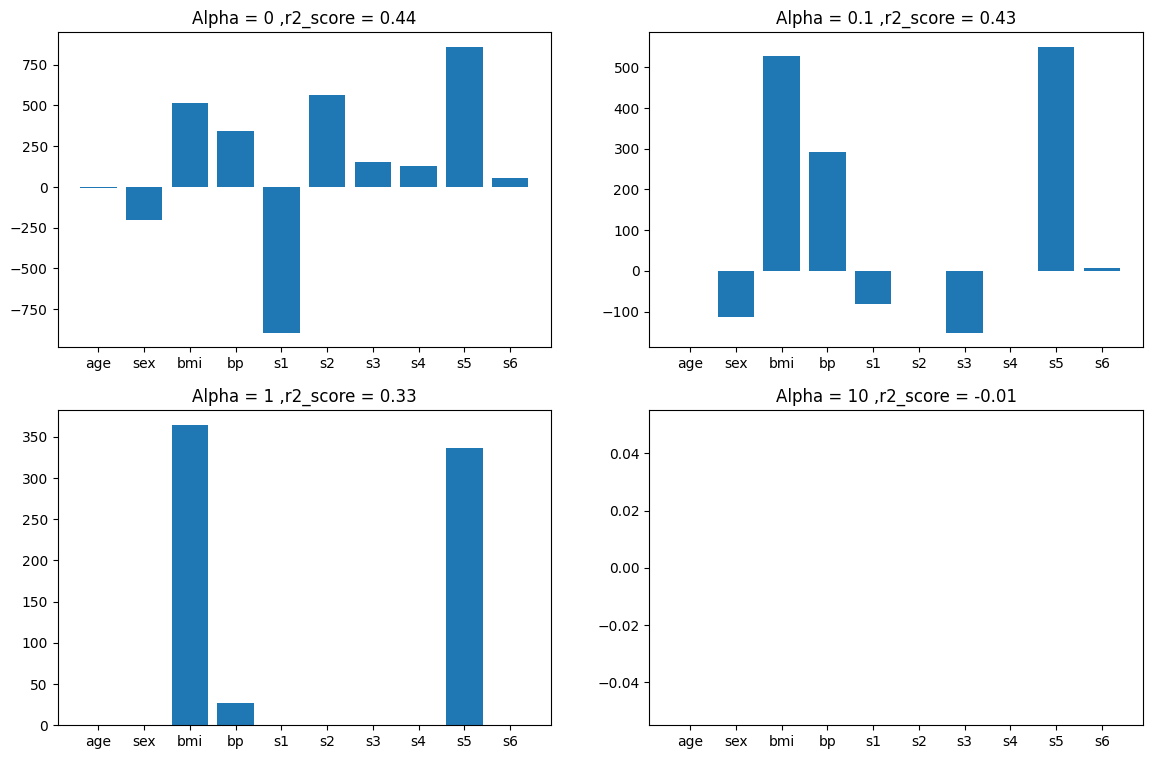

In [24]:
plt.figure(figsize=(14,9))
plt.subplot(221)
plt.bar(data.feature_names,coefs[0])
plt.title('Alpha = 0 ,r2_score = {}'.format(round(r2_scores[0],2)))

plt.subplot(222)
plt.bar(data.feature_names,coefs[1])
plt.title('Alpha = 0.1 ,r2_score = {}'.format(round(r2_scores[1],2)))

plt.subplot(223)
plt.bar(data.feature_names,coefs[2])
plt.title('Alpha = 1 ,r2_score = {}'.format(round(r2_scores[2],2)))

plt.subplot(224)
plt.bar(data.feature_names,coefs[3])
plt.title('Alpha = 10 ,r2_score = {}'.format(round(r2_scores[3],2)))

plt.show()

- Aaccording to lasso regression these 3 are most important columns for our dataset.

### **2. Higher Coefficents are More Affected**

In [25]:
alphas = [0,0.0001,0.001,0.01,0.1,1,10,100,1000,10000]
coefs = []
for i in alphas:
    reg = Lasso(alpha=i)
    reg.fit(X_train,y_train)
    coefs.append(reg.coef_.tolist())

In [26]:
input_array = np.array(coefs)
coef_df = pd.DataFrame(input_array,columns=data.feature_names)
coef_df['alpha'] = alphas
coef_df.set_index('alpha')

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
alpha,,,,,,,,,,
0.0000,-9.158653,-205.454322,516.693745,340.619999,-895.551989,561.220669,153.893104,126.731395,861.126997,52.421122
0.0001,-9.069064,-205.329406,516.789418,340.532379,-888.660904,555.958584,150.593655,125.450143,858.645541,52.380294
0.0010,-8.262770,-204.205364,517.650073,339.743901,-826.663603,508.617395,120.908607,113.921773,836.320753,52.012849
0.0100,-1.359721,-192.937180,526.356514,332.641101,-430.226975,191.295480,-44.034913,68.988987,688.396028,47.940616
0.1000,0.000000,-113.969928,526.744396,292.628472,-82.693681,-0.000000,-152.685338,0.000000,551.080291,7.170992
1.0000,0.000000,0.000000,363.885742,27.273163,0.000000,0.000000,-0.000000,0.000000,336.137262,0.000000
10.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000
100.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000
1000.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000


In [27]:
alphas = [0,0.0001,0.0005,0.001,0.005,0.1,0.5,1,5,10]
coefs = []
for i in alphas:
    reg = Lasso(alpha=i)
    reg.fit(X_train,y_train)
    coefs.append(reg.coef_.tolist())

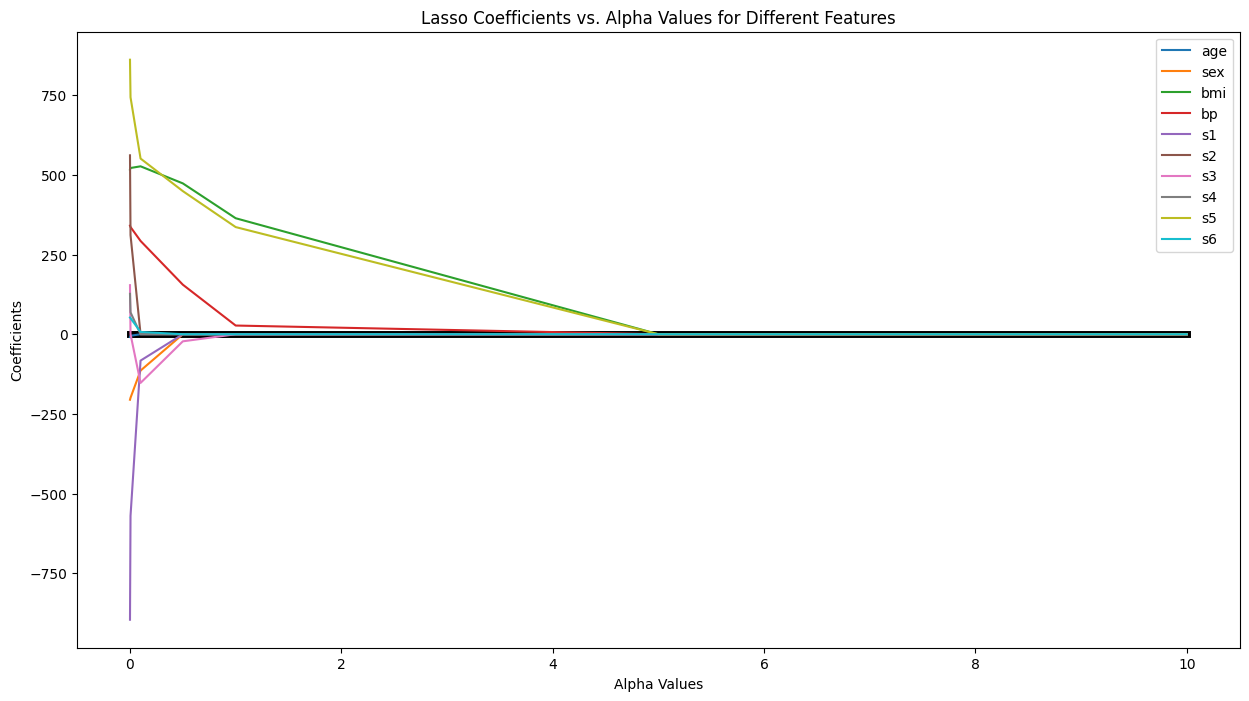

In [28]:
# Transpose the coefficients array for easier plotting
input_array = np.array(coefs).T

# Create a figure with specified size
plt.figure(figsize=(15, 8))

# Plot a baseline line at y=0 for reference
plt.plot(alphas, np.zeros(len(alphas)), color='black', linewidth=5)

# Iterate over each feature's coefficients to plot them against alpha values
for i in range(input_array.shape[0]):
    plt.plot(alphas, input_array[i], label=data.feature_names[i])  # Plot each feature's coefficients

# Add a legend to distinguish the lines
plt.legend()

# Label the x-axis and y-axis
plt.xlabel('Alpha Values')
plt.ylabel('Coefficients')

# Add a title to the plot
plt.title('Lasso Coefficients vs. Alpha Values for Different Features')

# Display the plot
plt.show()

### **3. Impact on Bias and Variance**

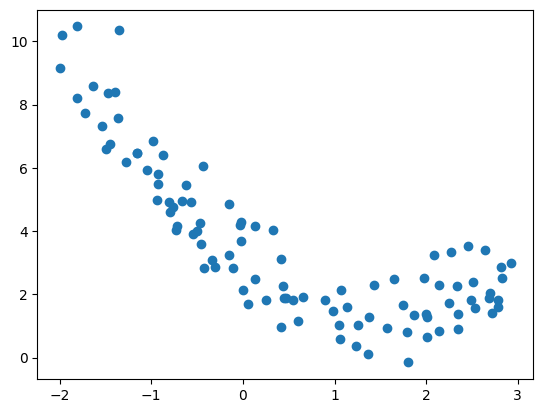

In [29]:
m = 100
X = 5 * np.random.rand(m, 1) - 2
y = 0.7 * X ** 2 - 2 * X + 3 + np.random.randn(m, 1)
plt.scatter(X, y)
plt.show()

In [30]:
X_train,X_test,y_train,y_test = train_test_split(X.reshape(100,1),y.reshape(100),test_size=0.2,random_state=2)

In [31]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=10)

X_train = poly.fit_transform(X_train)
X_test = poly.transform(X_test)

In [32]:
from mlxtend.evaluate import bias_variance_decomp
alphas = np.linspace(0,30,100)
loss = []
bias = []
variance = []

for i in alphas:
    reg = Lasso(alpha=i)
    avg_expected_loss, avg_bias, avg_var = bias_variance_decomp(
        reg, X_train, y_train, X_test, y_test, 
        loss='mse',
        random_seed=123)
    loss.append(avg_expected_loss)
    bias.append(avg_bias)
    variance.append(avg_var)

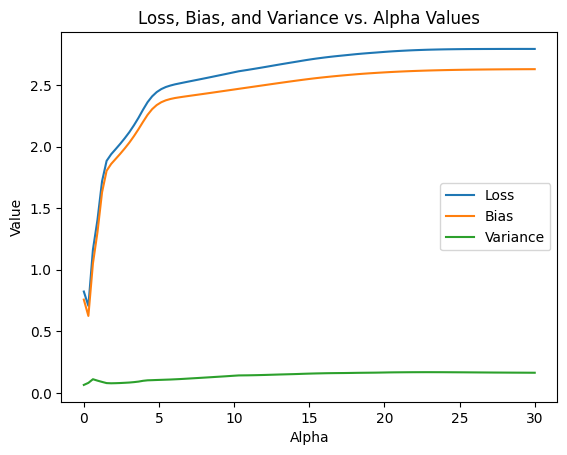

In [33]:
# Plot the loss against alpha values
plt.plot(alphas, loss, label='Loss')  # Loss curve

# Plot the bias against alpha values
plt.plot(alphas, bias, label='Bias')  # Bias curve

# Plot the variance against alpha values
plt.plot(alphas, variance, label='Variance')  # Variance curve

# Label the x-axis
plt.xlabel('Alpha')  # Alpha values for the regularization parameter

# Label the y-axis
plt.ylabel('Value')  # Values of loss, bias, and variance

# Add a legend to distinguish the lines
plt.legend()

# Add a title to the plot
plt.title('Loss, Bias, and Variance vs. Alpha Values')

# Display the plot
plt.show()

### **4. Effect of Regularization on Loss Function**

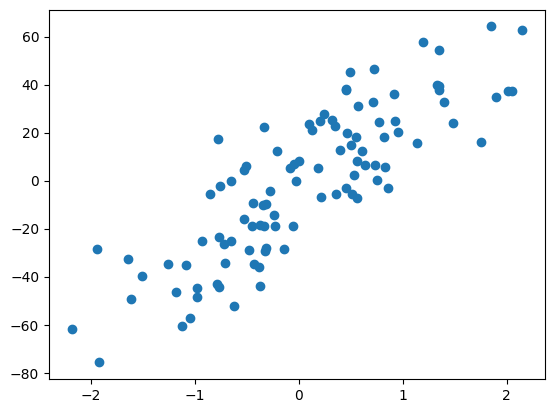

In [35]:
from sklearn.datasets import make_regression

X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)
plt.scatter(X,y)
plt.show()

In [36]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X,y)
print(reg.coef_)
print(reg.intercept_)

[27.82809103]
-2.29474455867698


In [37]:
def cal_loss(m,alpha):
    return np.sum((y - m*X.ravel() + 2.29)**2) + alpha*abs(m)

In [38]:
def predict(m):
    return m*X - 2.29

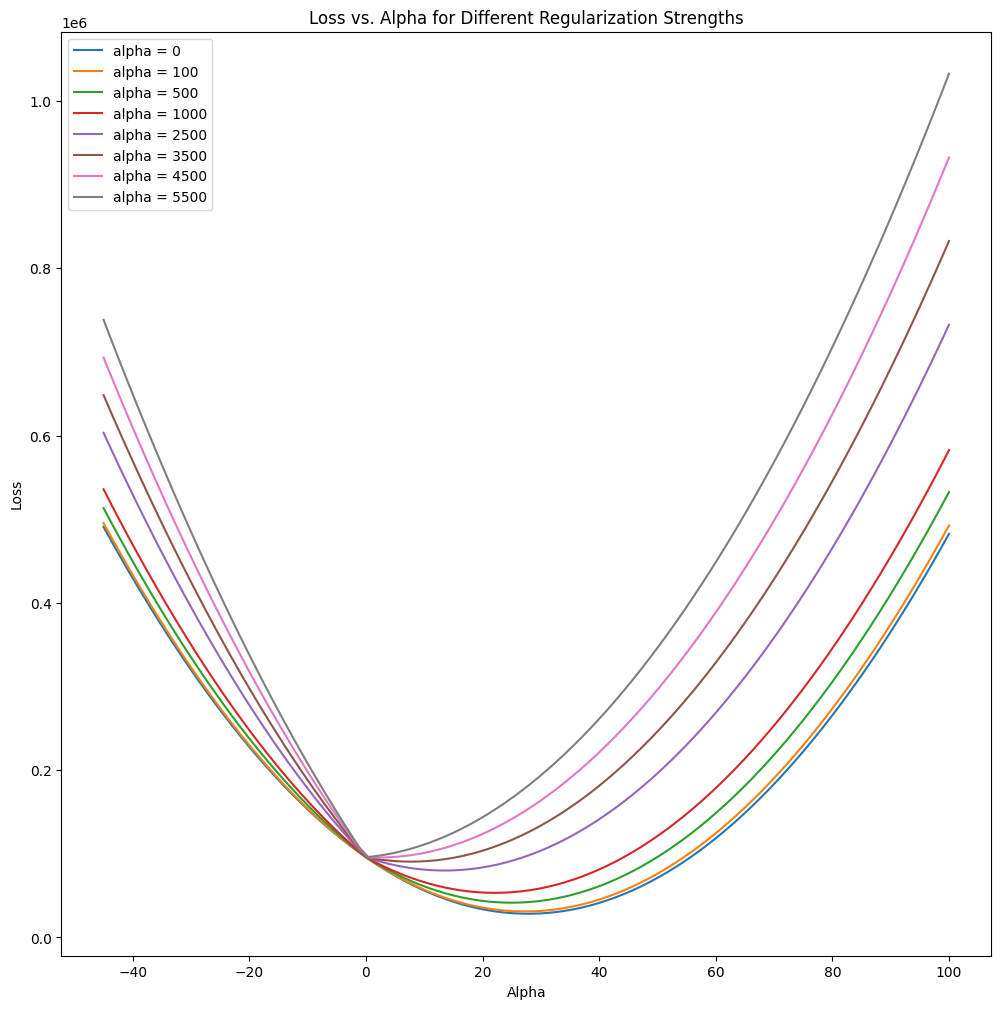

In [39]:
# Generate a range of alpha values from -45 to 100
m = np.linspace(-45, 100, 100)

# Create a figure with specified size
plt.figure(figsize=(12, 12))

# Iterate over specified alpha values
for j in [0, 100, 500, 1000, 2500, 3500, 4500, 5500]:
    loss = []  # Initialize a list to store loss values for the current alpha
    # Calculate loss for each value in the m array
    for i in range(m.shape[0]):
        loss_i = cal_loss(m[i], j)  # Calculate the loss using the custom function cal_loss
        loss.append(loss_i)  # Append the calculated loss to the list
    # Plot the loss against the alpha values for the current j
    plt.plot(m, loss, label='alpha = {}'.format(j))

# Add a legend to distinguish the lines
plt.legend()

# Label the x-axis and y-axis
plt.xlabel('Alpha')  # Label for the x-axis
plt.ylabel('Loss')   # Label for the y-axis

# Add a title to the plot
plt.title('Loss vs. Alpha for Different Regularization Strengths')  # Title of the plot

# Display the plot
plt.show()

---